# Supervised Anomaly Detection — Authentication Logs

This notebook applies **supervised** classification to the RBA (Risk-Based Authentication) dataset.
The true `Is Account Takeover` label is used **directly during training** to learn a decision boundary.

**Algorithms covered:**
- Logistic Regression
- Support Vector Machine (SVM)
- Decision Tree
- Random Forest

**Sampling strategy:** The original dataset is heavily imbalanced (Normal ≈ 31 M, Takeover = 141).
To make training tractable and reduce class imbalance, we undersample Normal rows so the final
dataset has **141 Takeover** and **14,100 Normal** rows — a 1 : 100 ratio.

**Feature set:** 6 numeric columns + 2 categorical columns.

**Class imbalance handling:** `class_weight='balanced'` is applied where supported;
for Decision Tree and Random Forest it is also available.

# 1. Import Libraries

In [1]:
import numpy as np
import pandas as pd
import ipaddress
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# --- Supervised Models ---
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# --- Metrics ---
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, roc_auc_score,
    classification_report, ConfusionMatrixDisplay
)

print('All libraries imported successfully.')

All libraries imported successfully.


# 2. Load Data

In [2]:
data = pd.read_csv('rba-dataset.csv')
print('Raw dataset shape:', data.shape)
data.head(3)

Raw dataset shape: (31269264, 16)


,index,Login Timestamp,User ID,Round-Trip Time [ms],IP Address,Country,Region,City,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover
0,0,2020-02-03 12:43:30.772,-4324475583306591935,NaN,10.0.65.171,NO,-,-,29695,Mozilla/5.0 (iPhone; CPU iPhone OS 13_4 like ...,Firefox 20.0.0.1618,iOS 13.4,mobile,False,False,False
1,1,2020-02-03 12:43:43.549,-4324475583306591935,NaN,194.87.207.6,AU,-,-,60117,Mozilla/5.0 (Linux; Android 4.1; Galaxy Nexus...,Chrome Mobile 46.0.2490,Android 4.1,mobile,False,False,False
2,2,2020-02-03 12:43:55.873,-3284137479262433373,NaN,81.167.144.58,NO,Vestland,Urangsvag,29695,Mozilla/5.0 (iPad; CPU OS 7_1 like Mac OS X) ...,Android 2.3.3.2672,iOS 7.1,mobile,True,False,False


## Preprocessing — identical to the unsupervised notebook

In [3]:
# Extract hour from timestamp
data['Login Hour'] = pd.to_datetime(data['Login Timestamp']).dt.hour

# Convert booleans to integers
data['Is Account Takeover'] = data['Is Account Takeover'].astype(np.uint8)
data['Is Attack IP']        = data['Is Attack IP'].astype(np.uint8)
data['Login Successful']    = data['Login Successful'].astype(np.uint8)

# Drop unused columns
data = data.drop(columns=['Round-Trip Time [ms]', 'Region', 'City', 'Login Timestamp', 'index'])

# Factorize high-cardinality string columns
data['User Agent String'],        _ = pd.factorize(data['User Agent String'])
data['Browser Name and Version'], _ = pd.factorize(data['Browser Name and Version'])
data['OS Name and Version'],      _ = pd.factorize(data['OS Name and Version'])

# Convert IP addresses to integers
def ip_to_int(ip):
    return int(ipaddress.ip_address(ip))

data['IP Address'] = data['IP Address'].apply(ip_to_int)

print('Shape after cleaning:', data.shape)
data.head(3)

Shape after cleaning: (31269264, 12)


,User ID,IP Address,Country,ASN,User Agent String,Browser Name and Version,OS Name and Version,Device Type,Login Successful,Is Attack IP,Is Account Takeover,Login Hour
0,-4324475583306591935,167788971,NO,29695,0,0,0,mobile,0,0,0,12
1,-4324475583306591935,3260534534,AU,60117,1,1,1,mobile,0,0,0,12
2,-3284137479262433373,1369935930,NO,29695,2,2,2,mobile,1,0,0,12


## Sampling — Undersample to 1 : 100 ratio

The original dataset has ~31 M Normal rows and only 141 Takeover rows.
Training on the full dataset would be extremely slow and numerically dominated by Normal behaviour.

**Strategy:** Keep all 141 Takeover rows and randomly sample 14,100 Normal rows (seed = 42),
giving a 1 : 100 Takeover : Normal ratio.

In [4]:
N_TAKEOVER = 141
N_NORMAL   = 14_100   # 1 : 100 ratio

takeover_rows = data[data['Is Account Takeover'] == 1]
normal_rows   = data[data['Is Account Takeover'] == 0].sample(n=N_NORMAL, random_state=42)

data_sampled = pd.concat([takeover_rows, normal_rows]).sample(frac=1, random_state=42).reset_index(drop=True)

print('Sampled dataset shape:', data_sampled.shape)
print()
print('Class distribution after sampling:')
print(data_sampled['Is Account Takeover'].value_counts().rename({0: 'Normal', 1: 'Takeover'}))

Sampled dataset shape: (14241, 12)

Class distribution after sampling:
Is Account Takeover
Normal      14100
Takeover      141
Name: count, dtype: int64


# 3. Feature Preparation

We use the same **8 features** as the unsupervised notebook:
- **Numeric (6):** `ASN`, `Login Hour`, `IP Address`, `User Agent String`,
  `Browser Name and Version`, `OS Name and Version`
- **Categorical (2):** `Country`, `Device Type`

Unlike the unsupervised approach, **labels ARE used during training** here.

In [5]:
numeric_cols     = ['ASN', 'Login Hour', 'IP Address',
                     'User Agent String', 'Browser Name and Version', 'OS Name and Version']
categorical_cols = ['Country', 'Device Type']

X = data_sampled[numeric_cols + categorical_cols]
y = data_sampled['Is Account Takeover']

print('Feature matrix shape:', X.shape)
print('\nClass distribution:')
print(y.value_counts().rename({0: 'Normal', 1: 'Takeover'}))

Feature matrix shape: (14241, 8)

Class distribution:
Is Account Takeover
Normal      14100
Takeover      141
Name: count, dtype: int64


# 4. Train-Test Split

80/20 split with `stratify=y` to preserve the 1 : 100 class ratio in both sets.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train: {len(X_train):,} rows  |  Test: {len(X_test):,} rows')
print(f'Takeover rate — train: {y_train.mean():.4%}  |  test: {y_test.mean():.4%}')

print('\n--- Train label distribution ---')
print(y_train.value_counts().rename({0: 'Normal', 1: 'Takeover'}).to_string())

print('\n--- Test label distribution ---')
print(y_test.value_counts().rename({0: 'Normal', 1: 'Takeover'}).to_string())

Train: 11,392 rows  |  Test: 2,849 rows
Takeover rate — train: 0.9919%  |  test: 0.9828%

--- Train label distribution ---
Is Account Takeover
Normal      11279
Takeover      113

--- Test label distribution ---
Is Account Takeover
Normal      2821
Takeover      28


## Preprocessing Pipeline

Numeric features are standardised; categorical features are one-hot encoded.
We build a reusable `preprocessor` that is embedded inside each model's `Pipeline`
so there is no data leakage between train and test.

In [7]:
def make_preprocessor():
    return ColumnTransformer(transformers=[
        ('num', StandardScaler(),                        numeric_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_cols)
    ])

print('Preprocessor factory ready.')

Preprocessor factory ready.


## Evaluation Helper

We define a shared `evaluate()` function that computes all metrics and stores them
in a list for the final comparison table.

In [8]:
results = []  # accumulate rows for summary table

def evaluate(name, split, y_true, y_pred, y_prob):
    """
    Print full metrics and return a summary dict.
    y_prob : probability or decision score for the positive class (Takeover = 1)
    """
    print(f'\n{"="*60}')
    print(f'  {name}  |  {split} set')
    print(f'{"="*60}')
    print(f'  Accuracy  : {accuracy_score(y_true, y_pred):.4f}')
    print(f'  Precision : {precision_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  Recall    : {recall_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  F1-score  : {f1_score(y_true, y_pred, zero_division=0):.4f}')
    print(f'  ROC AUC   : {roc_auc_score(y_true, y_prob):.4f}')
    print('\n  Confusion Matrix (rows=actual, cols=predicted):')
    print(f'  Labels: 0=Normal  1=Takeover')
    print(confusion_matrix(y_true, y_pred))
    print()
    print(classification_report(y_true, y_pred,
                                target_names=['Normal', 'Takeover'],
                                zero_division=0))
    return {
        'Model'    : name,
        'Split'    : split,
        'Accuracy' : round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, zero_division=0), 4),
        'Recall'   : round(recall_score(y_true, y_pred, zero_division=0), 4),
        'F1'       : round(f1_score(y_true, y_pred, zero_division=0), 4),
        'ROC AUC'  : round(roc_auc_score(y_true, y_prob), 4),
    }

print('evaluate() helper ready.')

evaluate() helper ready.


# 5. Logistic Regression

A linear probabilistic classifier. `class_weight='balanced'` reweights the loss
so the minority class (Takeover) has proportionally more influence during training.
`max_iter=1000` ensures convergence on the preprocessed feature space.

In [9]:
lr_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   LogisticRegression(
                        class_weight='balanced',
                        max_iter=1000,
                        random_state=42
                    ))
])

lr_pipeline.fit(X_train, y_train)
print('Logistic Regression trained.')

Logistic Regression trained.


In [10]:
# Train set
lr_train_pred = lr_pipeline.predict(X_train)
lr_train_prob = lr_pipeline.predict_proba(X_train)[:, 1]
results.append(evaluate('Logistic Regression', 'Train', y_train, lr_train_pred, lr_train_prob))

# Test set
lr_test_pred = lr_pipeline.predict(X_test)
lr_test_prob = lr_pipeline.predict_proba(X_test)[:, 1]
results.append(evaluate('Logistic Regression', 'Test', y_test, lr_test_pred, lr_test_prob))


  Logistic Regression  |  Train set
  Accuracy  : 0.9494
  Precision : 0.1548
  Recall    : 0.9204
  F1-score  : 0.2650
  ROC AUC   : 0.9828

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[10711   568]
 [    9   104]]

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97     11279
    Takeover       0.15      0.92      0.26       113

    accuracy                           0.95     11392
   macro avg       0.58      0.93      0.62     11392
weighted avg       0.99      0.95      0.97     11392


  Logistic Regression  |  Test set
  Accuracy  : 0.9442
  Precision : 0.1341
  Recall    : 0.8571
  F1-score  : 0.2319
  ROC AUC   : 0.9807

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[2666  155]
 [   4   24]]

              precision    recall  f1-score   support

      Normal       1.00      0.95      0.97      2821
    Takeover       0.13      0.86      0.23        28

  

# 6. Support Vector Machine (SVM)

Uses an RBF kernel to find a nonlinear decision boundary in feature space.
`class_weight='balanced'` handles the 1:100 imbalance.
`probability=True` enables `predict_proba` for ROC AUC computation.

In [11]:
svm_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   SVC(
                        kernel='rbf',
                        class_weight='balanced',
                        probability=True,
                        random_state=42
                    ))
])

print(f'Fitting SVM on {len(X_train):,} samples...')
svm_pipeline.fit(X_train, y_train)
print('SVM trained.')

Fitting SVM on 11,392 samples...
SVM trained.


In [12]:
# Train set
svm_train_pred = svm_pipeline.predict(X_train)
svm_train_prob = svm_pipeline.predict_proba(X_train)[:, 1]
results.append(evaluate('SVM (RBF)', 'Train', y_train, svm_train_pred, svm_train_prob))

# Test set
svm_test_pred = svm_pipeline.predict(X_test)
svm_test_prob = svm_pipeline.predict_proba(X_test)[:, 1]
results.append(evaluate('SVM (RBF)', 'Test', y_test, svm_test_pred, svm_test_prob))


  SVM (RBF)  |  Train set
  Accuracy  : 0.9800
  Precision : 0.3304
  Recall    : 0.9912
  F1-score  : 0.4956
  ROC AUC   : 0.9986

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[11052   227]
 [    1   112]]

              precision    recall  f1-score   support

      Normal       1.00      0.98      0.99     11279
    Takeover       0.33      0.99      0.50       113

    accuracy                           0.98     11392
   macro avg       0.67      0.99      0.74     11392
weighted avg       0.99      0.98      0.98     11392


  SVM (RBF)  |  Test set
  Accuracy  : 0.9726
  Precision : 0.2396
  Recall    : 0.8214
  F1-score  : 0.3710
  ROC AUC   : 0.9498

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[2748   73]
 [   5   23]]

              precision    recall  f1-score   support

      Normal       1.00      0.97      0.99      2821
    Takeover       0.24      0.82      0.37        28

    accuracy          

# 7. Decision Tree

A non-parametric model that learns axis-aligned splits.
`max_depth=10` limits tree depth to reduce overfitting.
`class_weight='balanced'` handles imbalance by upweighting Takeover samples.

In [13]:
dt_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   DecisionTreeClassifier(
                        max_depth=10,
                        class_weight='balanced',
                        random_state=42
                    ))
])

dt_pipeline.fit(X_train, y_train)
print('Decision Tree trained.')

Decision Tree trained.


In [14]:
# Train set
dt_train_pred = dt_pipeline.predict(X_train)
dt_train_prob = dt_pipeline.predict_proba(X_train)[:, 1]
results.append(evaluate('Decision Tree', 'Train', y_train, dt_train_pred, dt_train_prob))

# Test set
dt_test_pred = dt_pipeline.predict(X_test)
dt_test_prob = dt_pipeline.predict_proba(X_test)[:, 1]
results.append(evaluate('Decision Tree', 'Test', y_test, dt_test_pred, dt_test_prob))


  Decision Tree  |  Train set
  Accuracy  : 0.9972
  Precision : 0.7832
  Recall    : 0.9912
  F1-score  : 0.8750
  ROC AUC   : 0.9999

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[11248    31]
 [    1   112]]

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     11279
    Takeover       0.78      0.99      0.88       113

    accuracy                           1.00     11392
   macro avg       0.89      0.99      0.94     11392
weighted avg       1.00      1.00      1.00     11392


  Decision Tree  |  Test set
  Accuracy  : 0.9944
  Precision : 0.7000
  Recall    : 0.7500
  F1-score  : 0.7241
  ROC AUC   : 0.8732

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[2812    9]
 [   7   21]]

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2821
    Takeover       0.70      0.75      0.72        28

    accuracy  

# 8. Random Forest

An ensemble of 100 decision trees trained on bootstrap samples.
Reduces variance compared to a single Decision Tree.
`class_weight='balanced'` handles imbalance;
`n_jobs=-1` parallelises training across all CPU cores.

In [15]:
rf_pipeline = Pipeline(steps=[
    ('preprocessor', make_preprocessor()),
    ('classifier',   RandomForestClassifier(
                        n_estimators=100,
                        max_depth=10,
                        class_weight='balanced',
                        random_state=42,
                        n_jobs=-1
                    ))
])

print('Fitting Random Forest...')
rf_pipeline.fit(X_train, y_train)
print('Random Forest trained.')

Fitting Random Forest...
Random Forest trained.


In [16]:
# Train set
rf_train_pred = rf_pipeline.predict(X_train)
rf_train_prob = rf_pipeline.predict_proba(X_train)[:, 1]
results.append(evaluate('Random Forest', 'Train', y_train, rf_train_pred, rf_train_prob))

# Test set
rf_test_pred = rf_pipeline.predict(X_test)
rf_test_prob = rf_pipeline.predict_proba(X_test)[:, 1]
results.append(evaluate('Random Forest', 'Test', y_test, rf_test_pred, rf_test_prob))


  Random Forest  |  Train set
  Accuracy  : 0.9990
  Precision : 0.9397
  Recall    : 0.9646
  F1-score  : 0.9520
  ROC AUC   : 0.9999

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[11272     7]
 [    4   109]]

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     11279
    Takeover       0.94      0.96      0.95       113

    accuracy                           1.00     11392
   macro avg       0.97      0.98      0.98     11392
weighted avg       1.00      1.00      1.00     11392


  Random Forest  |  Test set
  Accuracy  : 0.9965
  Precision : 0.9091
  Recall    : 0.7143
  F1-score  : 0.8000
  ROC AUC   : 0.9865

  Confusion Matrix (rows=actual, cols=predicted):
  Labels: 0=Normal  1=Takeover
[[2819    2]
 [   8   20]]

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00      2821
    Takeover       0.91      0.71      0.80        28

    accuracy  

# 9. Results Comparison

The table below summarises all model-split combinations.

> **Key metrics for imbalanced anomaly detection:**
> - **Recall** — what fraction of real takeovers were caught (missing one is costly).
> - **ROC AUC** — overall separability regardless of threshold.
> - **F1** — harmonic mean of precision and recall; useful when both matter.
> - Watch for **train vs test gap** — a large gap signals overfitting.

In [17]:
summary = pd.DataFrame(results).set_index(['Model', 'Split'])
print(summary.to_string())

                           Accuracy  Precision  Recall      F1  ROC AUC
Model               Split                                              
Logistic Regression Train    0.9494     0.1548  0.9204  0.2650   0.9828
                    Test     0.9442     0.1341  0.8571  0.2319   0.9807
SVM (RBF)           Train    0.9800     0.3304  0.9912  0.4956   0.9986
                    Test     0.9726     0.2396  0.8214  0.3710   0.9498
Decision Tree       Train    0.9972     0.7832  0.9912  0.8750   0.9999
                    Test     0.9944     0.7000  0.7500  0.7241   0.8732
Random Forest       Train    0.9990     0.9397  0.9646  0.9520   0.9999
                    Test     0.9965     0.9091  0.7143  0.8000   0.9865


# 10. Visualisation — Test Set Metrics Bar Chart

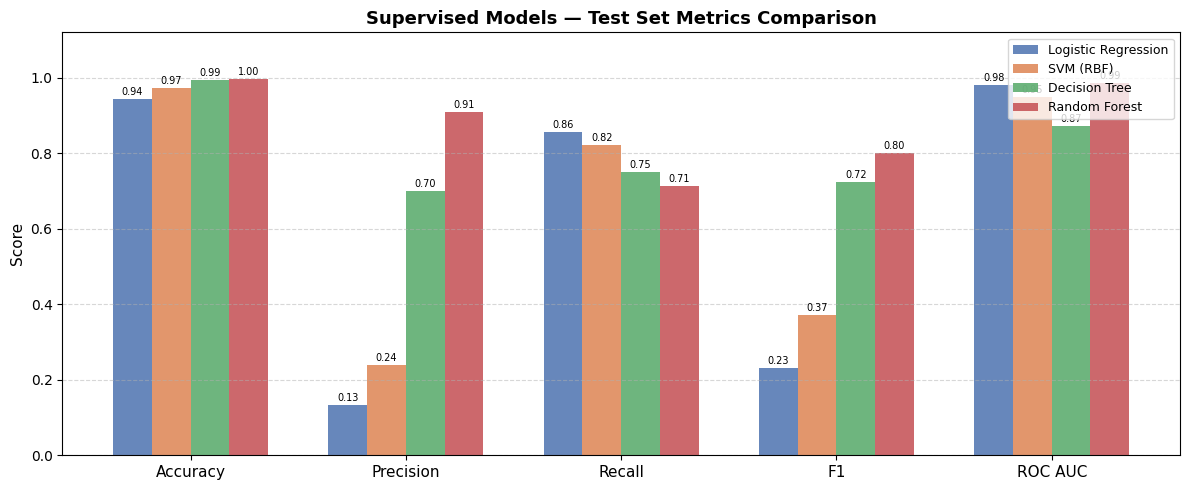

Chart saved as supervised_metrics_comparison.png


In [18]:
test_results = summary.xs('Test', level='Split')

metrics = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC AUC']
x       = np.arange(len(metrics))
width   = 0.18
colors  = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']

fig, ax = plt.subplots(figsize=(12, 5))

for i, (model_name, row) in enumerate(test_results.iterrows()):
    offset = (i - 1.5) * width
    bars   = ax.bar(x + offset, row[metrics], width, label=model_name, color=colors[i], alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.005,
                f'{h:.2f}', ha='center', va='bottom', fontsize=7)

ax.set_xticks(x)
ax.set_xticklabels(metrics, fontsize=11)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Supervised Models — Test Set Metrics Comparison', fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9)
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('supervised_metrics_comparison.png', dpi=150)
plt.show()
print('Chart saved as supervised_metrics_comparison.png')

# 11. Confusion Matrices — Test Set

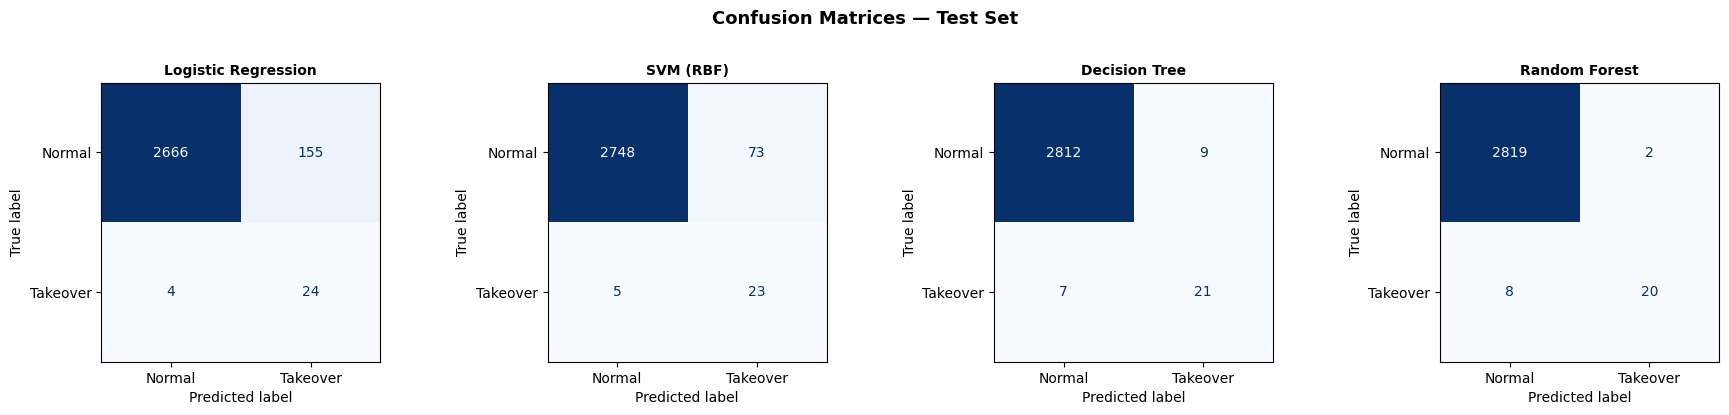

Confusion matrices saved as supervised_confusion_matrices.png


In [19]:
model_info = [
    ('Logistic Regression', lr_test_pred),
    ('SVM (RBF)',           svm_test_pred),
    ('Decision Tree',       dt_test_pred),
    ('Random Forest',       rf_test_pred),
]

fig, axes = plt.subplots(1, 4, figsize=(18, 4))

for ax, (name, preds) in zip(axes, model_info):
    cm   = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                                  display_labels=['Normal', 'Takeover'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=10, fontweight='bold')

plt.suptitle('Confusion Matrices — Test Set', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('supervised_confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()
print('Confusion matrices saved as supervised_confusion_matrices.png')

# 12. Feature Importances — Random Forest

Random Forest provides built-in feature importances (mean decrease in impurity).
This shows which features contribute most to detecting account takeovers.

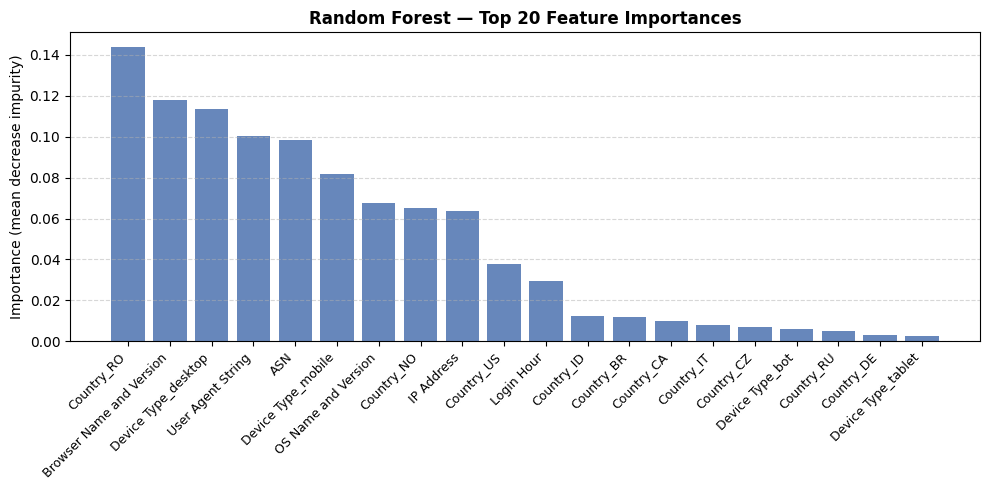

Feature importances saved as rf_feature_importances.png


In [20]:
rf_clf          = rf_pipeline.named_steps['classifier']
ohe_features    = rf_pipeline.named_steps['preprocessor'] \
                    .named_transformers_['cat'] \
                    .get_feature_names_out(categorical_cols).tolist()
all_feature_names = numeric_cols + ohe_features

importances = rf_clf.feature_importances_
sorted_idx  = np.argsort(importances)[::-1][:20]  # top 20

fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(range(len(sorted_idx)),
       importances[sorted_idx],
       color='#4C72B0', alpha=0.85)
ax.set_xticks(range(len(sorted_idx)))
ax.set_xticklabels([all_feature_names[i] for i in sorted_idx],
                   rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Importance (mean decrease impurity)', fontsize=10)
ax.set_title('Random Forest — Top 20 Feature Importances', fontsize=12, fontweight='bold')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('rf_feature_importances.png', dpi=150)
plt.show()
print('Feature importances saved as rf_feature_importances.png')